## 2024-11-08

### Authors
* Nicole Tin (nicole@velexi.com)


### Future Ideas
* benchmark with professional dermatologists estimate (+-10 yrs)
  * professional skin attribute assessment
     * is this feature something we can model?
* inter-group variability
* ML nor doctors may not be good at identifying biological age
* scientifically, there may be more group variability
* one person in training/test split as L/R hands
  * should it be strictly L or R? Is this data leakage?
  * train only on L, test on R, would outcomes be perfect? high error? 


### EDA ideas (age vs sun exposure)
* L vs. R
* inter age

### Current Tasks:
Email Dr. Powers with updates, and updated correlation findings
  - Craft interesting questions ("a research proposal"; incorporate literature)
     - Progress so far
     - Interesting finds
     - Possible avenues in coming months
     - Literature , annotator agreement
  - Some work involved in formulating an interesting research question
- Propose interesting questions (start a discussion) with derms to generate interest
- Avenues for collaboration and investigation on each side

### Preparations

In [1]:
# Paths
src_dir = '/Users/ntin/Downloads/DermaML_local/hawkeye-hands-2024-07-29'
# image_dir = '/processed_images/'
csv_file = '/metadata.csv'
texture_features_file = '/Users/ntin/DermaML/notebooks/2024-08-01_NT_Hawkeye-Hands-Texture-Features.csv'

In [2]:
# --- Imports

# Internal library

# Standard library
import random 
import math
import seaborn as sns
# External packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Entropy
random.seed(42)
np.random.seed(42)

np.set_printoptions(precision=3, suppress=True)

In [3]:
metadata = pd.read_csv(src_dir+ csv_file)
metadata.loc[:, 'Age'] = 2024-metadata['birth_year']
valid_image_fnames_df = pd.DataFrame(metadata.set_index('Age').loc[:, ['right_hand_image_file', 'left_hand_image_file']].stack()).reset_index()
valid_image_fnames_df.columns = ['Age', 'handedness', 'filename']
valid_image_fnames_df.loc[:,'filename'] = valid_image_fnames_df['filename'].apply(lambda x: x[:-5])
valid_image_fnames_df = valid_image_fnames_df.drop(index=[12,13])
valid_image_fnames = valid_image_fnames_df['filename'].to_numpy()
y = valid_image_fnames_df.loc[:, 'Age'].to_numpy()

In [4]:
texture_features = pd.read_csv(texture_features_file)
texture_features = texture_features.drop(columns=['Unnamed: 0',])

# data cleaning and preprocessing
outliers = texture_features[texture_features.Age > 200]
texture_features = texture_features.drop(index=outliers.index)
texture_features.loc[:, 'Age'] = np.around(texture_features.loc[:, 'Age']/5, decimals=0)*5

# take the norm of the top features
top_shap = ["relative_redness_std", "GLCM_SumEntropy_Mean_wrinkles_pyfeats", "skin_folds_hessian", "correlation_scikit", "lbp_6", "lbp_5", "lbp_4", "lbp_3",]
norm_texture = (texture_features[top_shap] - texture_features[top_shap].mean())/texture_features[top_shap].std()
norm_texture.loc[:, "Age"] = texture_features.loc[:, 'Age']

### Variability in Texture wrt Age

In [5]:
norm_texture.value_counts('Age')

Age
20     110
25      80
30      54
35      42
40      36
65      34
70      34
60      32
45      28
50      26
55      22
75      18
80      18
90      16
95      10
85      10
0        2
100      2
Name: count, dtype: int64

In [6]:
norm_texture.groupby('Age').mean()

,relative_redness_std,GLCM_SumEntropy_Mean_wrinkles_pyfeats,skin_folds_hessian,correlation_scikit,lbp_6,lbp_5,lbp_4,lbp_3
Age,,,,,,,,
0,-0.806842,0.586099,-0.382868,1.035954,-1.782038,-1.674782,-1.657422,-1.769276
20,0.473527,-0.260166,0.544444,0.703235,-0.311136,-0.525756,-0.556670,-0.308446
25,0.228007,-0.368592,0.138267,0.139949,-0.598229,-0.599202,-0.643027,-0.666912
30,0.128419,0.017239,0.090345,-0.102785,-0.300804,-0.358961,-0.362866,-0.330597
35,-0.024852,-0.517277,0.082336,0.075009,-0.469854,-0.463820,-0.508997,-0.528024
40,-0.254825,-0.401490,-0.181126,0.253832,-0.246764,-0.208474,-0.219811,-0.278534
45,-0.732909,0.363919,0.102798,-0.035135,-0.151087,-0.076696,-0.032491,-0.109060
50,-0.123489,0.436183,-0.103564,-0.035626,0.137181,0.198309,0.263880,0.217831
55,0.131221,-0.251079,-0.487014,-0.485988,0.547495,0.452192,0.408101,0.413575


In [7]:
norm_texture.groupby('Age').std()

,relative_redness_std,GLCM_SumEntropy_Mean_wrinkles_pyfeats,skin_folds_hessian,correlation_scikit,lbp_6,lbp_5,lbp_4,lbp_3
Age,,,,,,,,
0,0.055363,0.187465,0.193324,0.001218,0.022084,0.015620,0.033865,0.021567
20,1.100723,0.988529,1.180667,0.332556,0.594469,0.426414,0.432416,0.622894
25,0.800860,0.749663,0.871230,0.984852,0.736324,0.617238,0.585893,0.691708
30,0.882679,1.018700,0.816312,0.987432,0.879393,0.769414,0.771109,0.863378
35,1.542750,1.322035,1.717557,0.993639,0.715157,0.680411,0.652978,0.751077
40,1.063774,0.818493,0.565117,0.773771,0.722018,0.608792,0.589339,0.701182
45,1.230381,1.135020,1.431418,0.967347,1.026942,0.917627,0.883019,0.934040
50,0.871240,0.899038,0.628973,0.862001,0.841812,0.795876,0.798574,0.807845
55,0.495330,0.894778,0.350586,1.215101,0.882005,0.728157,0.605790,0.805946


### w Metadata

need to merge filenames and L/R filenames

In [8]:
right_hands = metadata.drop(columns=['left_hand_image_file']).set_index('right_hand_image_file')
left_hands = metadata.drop(columns=['right_hand_image_file']).set_index('left_hand_image_file')
hand_metadata = pd.concat([left_hands, right_hands], keys=['left_hand_image_file', 'right_hand_image_file']).rename_axis(['hand_image_file','filename'])
hand_metadata = hand_metadata.reset_index()
hand_metadata.shape

(626, 20)

In [9]:
hand_metadata.columns

Index(['hand_image_file', 'filename', 'record_id', 'gender', 'gender_specify',
       'birth_year', 'sex_assigned_at_birth', 'sex_assigned_at_birth_specify',
       'race_ethnicity', 'race_ethnicity_specify', 'ethnicity', 'handedness',
       'occupation', 'driving_time', 'sun_exposure', 'sunscreen_use', 'region',
       'region_specify', 'form_complete', 'Age'],
      dtype='object')

In [10]:
texture_features.loc[:,'filename'] = texture_features.loc[:,'filename'] + '.jpeg'

keep_features = top_shap + ['Age', 'filename']
keep_metadata = ['filename','gender', 'sex_assigned_at_birth', 'race_ethnicity', 'handedness', 'occupation', 'driving_time', 'sun_exposure', 'sunscreen_use', 'region']
eda_metadata = pd.get_dummies(
    hand_metadata[keep_metadata].set_index('filename')
    )

eda = pd.concat(
    [
        eda_metadata, 
        texture_features[keep_features].set_index('filename')
     ], join='inner', axis=1).reset_index(drop=True)

In [11]:
sex_gender_columns = ['gender_Gender queer or gender fluid', 'gender_Man',
       'gender_Non-binary or not exclusively man or woman', 'gender_Woman',
       'sex_assigned_at_birth_Female', 'sex_assigned_at_birth_Male',
       'sex_assigned_at_birth_Prefer not to say',]

race_ethnicity_columns = ['race_ethnicity_African-American/Black', 'race_ethnicity_Asian',
       'race_ethnicity_Caucasian/White',
       'race_ethnicity_Caucasian/White,African-American/Black',
       'race_ethnicity_Caucasian/White,American Indian/Alaska National',
       'race_ethnicity_Caucasian/White,Asian']

occupation_columns = ['occupation_Architecture/Engineering',
       'occupation_Building/Ground Cleaning and Maintenance',
       'occupation_Caretaking/Stay at Home Parent',
       'occupation_Community and Social Services',
       'occupation_Computer/Mathematical', 'occupation_Construction',
       'occupation_Education, Training, Library',
       'occupation_Farming/Fishing/Forestry',
       'occupation_Food Preparation/Serving', 'occupation_Healthcare/Medical',
       'occupation_Installation/Maintenance/Repair', 'occupation_Legal',
       'occupation_Office and Administrative Support',
       'occupation_Sales/Marketing', 'occupation_Student',
       'occupation_Transportation', 'occupation_Unemployed']

driving_columns = ['driving_time_30 minutes or less', 'driving_time_30-60 minutes',
       'driving_time_60+ minutes', ]

sun_columns = ['sun_exposure_1 hour', 'sun_exposure_2 hours', 'sun_exposure_3 hours',
       'sun_exposure_4 hours', 'sun_exposure_5+ hours',
       'sun_exposure_less than 30 minutes', 'sunscreen_use_Almost always',
       'sunscreen_use_Never', 'sunscreen_use_Rarely',
       'sunscreen_use_Sometimes',]

region_columns = ['region_Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, IN, MI, OH)',
       'region_Noncontiguous (HI, AK)',
       'region_Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)', 'region_Other',
       'region_Pacific (WA, OR, CA)',
       'region_Rocky Mountains (ID, MT, WY, NV, UT, CO)',
       'region_Southeast (AR, LA, MS, TN, KY, WV, VA, NC, SC, GA, AL, FL, DL, MD, DC)',
       'region_Southwest (AZ, NM, TX, OK)']

In [25]:
eda[occupation_columns].sum()

occupation_Architecture/Engineering                     46
occupation_Building/Ground Cleaning and Maintenance      4
occupation_Caretaking/Stay at Home Parent                8
occupation_Community and Social Services                 6
occupation_Computer/Mathematical                        24
occupation_Construction                                  4
occupation_Education, Training, Library                 48
occupation_Farming/Fishing/Forestry                      4
occupation_Food Preparation/Serving                     26
occupation_Healthcare/Medical                          154
occupation_Installation/Maintenance/Repair               2
occupation_Legal                                         4
occupation_Office and Administrative Support            44
occupation_Sales/Marketing                              38
occupation_Student                                     142
occupation_Transportation                                6
occupation_Unemployed                                   

<Axes: >

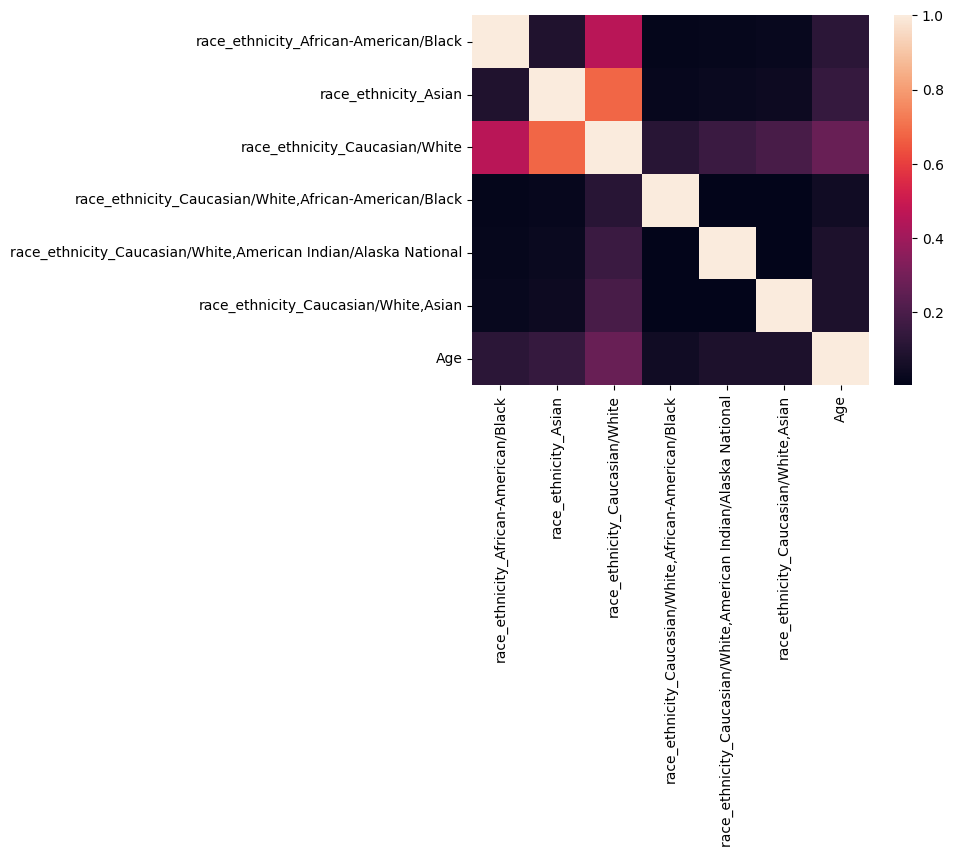

In [ ]:
sns.heatmap(eda[race_ethnicity_columns+['Age']].corr().abs())

<Axes: >

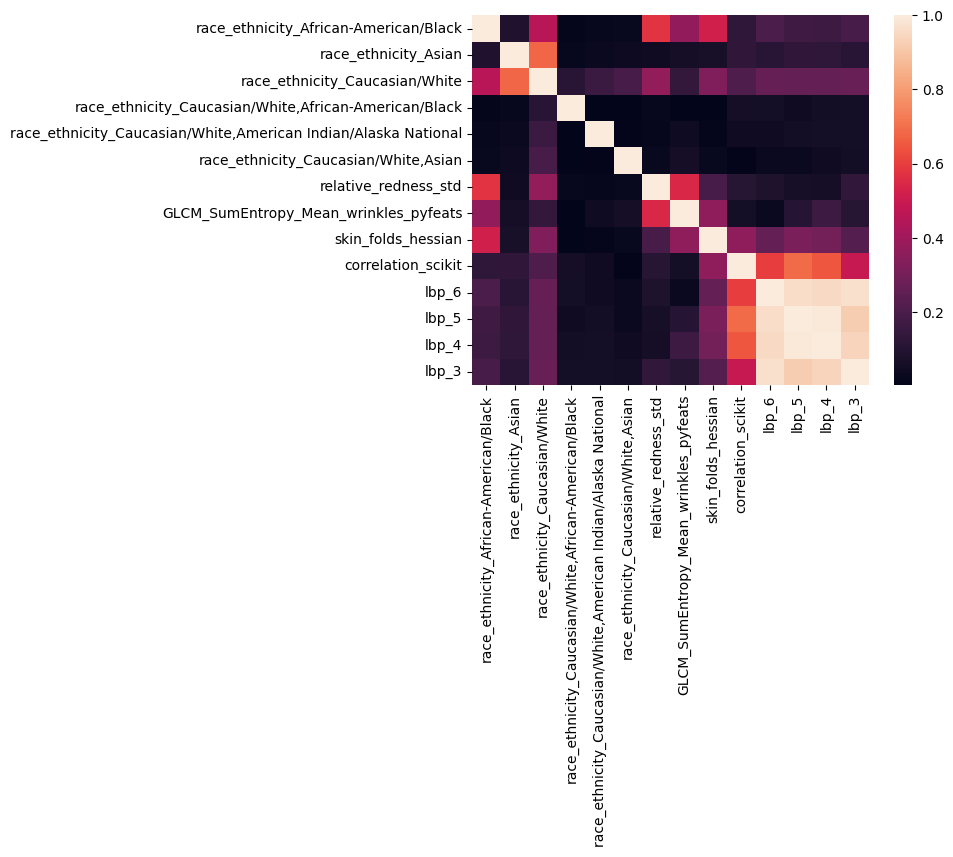

In [16]:
# %matplotlib inline
# sns.pairplot(data = eda,
#              x_vars=race_ethnicity_columns,
#              y_vars=top_shap)
# plt.show()
sns.heatmap(eda[race_ethnicity_columns+top_shap].corr().abs())

<Axes: >

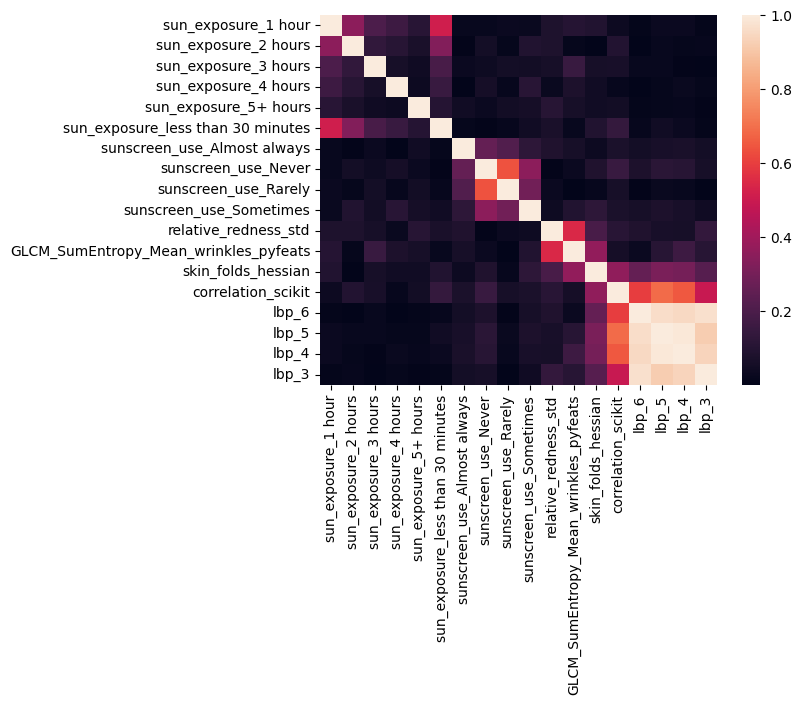

In [19]:
# sns.pairplot(data = eda,
#              x_vars=sun_columns,
#              y_vars=top_shap)
sns.heatmap(eda[sun_columns+top_shap].corr().abs())

<Axes: >

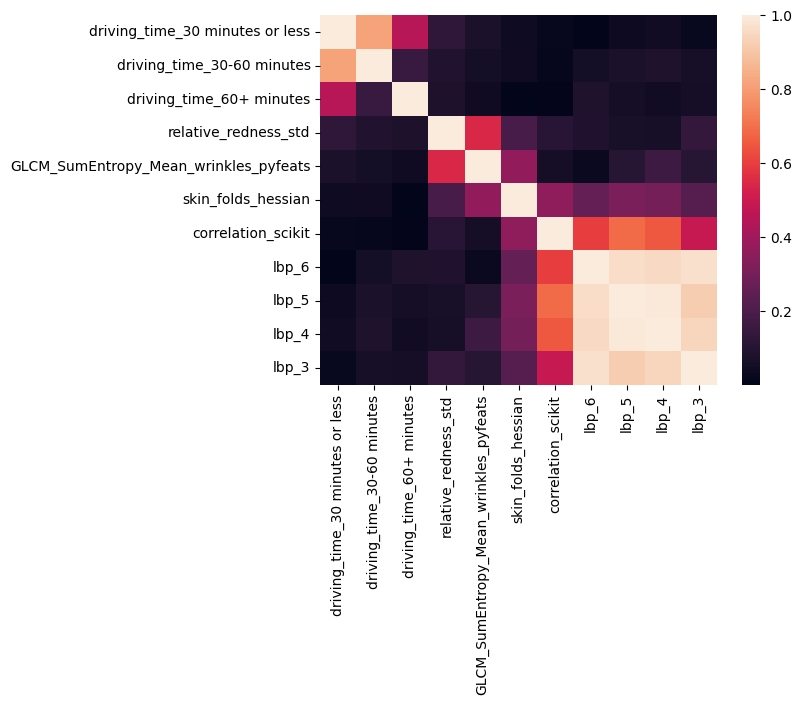

In [22]:
# sns.pairplot(data = eda,
#              x_vars=driving_columns,
#              y_vars=top_shap)

sns.heatmap(eda[driving_columns+top_shap].corr().abs())